In [9]:
from sklearn.datasets import make_regression 
import numpy as np 
import torch
from sklearn.model_selection import train_test_split
import random

In [10]:
import torch

# this is single feature dataset
x, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=42
)

# make_regression returns numpy arrays -> convert to torch tensors
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# starting guess for the line: y = w*x + b
w = torch.tensor(2.0)   # weight (slope)
b = torch.tensor(3.0)   # bias  (intercept)

print(x.shape)
print(y.shape)

torch.Size([100, 1])
torch.Size([100])


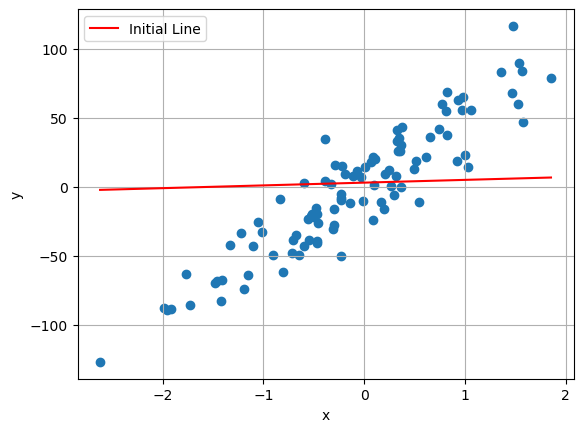

In [11]:
import matplotlib.pyplot as plt

# scatter = all 100 real data points (the dots)
plt.scatter(x.numpy(), y.numpy())

# ---------------------------------------------------------------------------
# Drawing the guess line  y = w*x + b
#
# A straight line is fully defined by just TWO points. So instead of computing
# y for all 100 x's, we only take the LEFT edge (min x) and RIGHT edge (max x),
# find the line's height (y) at each, and let matplotlib connect them.
#
#   x_ends = [min x , max x]        <- the two edge x-values
#   y_ends = w * x_ends + b         <- line height at each edge
#
#        y |              ● (max x , y_ends[1])
#          |           
#          |                <- plt.plot draws ONE straight line
#          |                  between these two dots
#          |  ● (min x , y_ends[0])
#          +-------------------- x
#
# (the dots from scatter sit underneath; this red line is our w,b guess)
# ---------------------------------------------------------------------------
x_ends = torch.tensor([x.min().item(), x.max().item()])
y_ends = w * x_ends + b 

plt.plot(x_ends.numpy(), y_ends.numpy(), 'r', label='Initial Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
def SGD(Loss, W, B, X_k, t, C=0.1):
    """ 
    let w, b be defined as A
    
    A_k+1 = A_k + learning_rate_k * gradient(f_i k) 
    
    k defines the randomly choosen indexes for dataset
    We only have a single feature so we don't have to randomize weight and bias. 
    If we had multiple features, which would produce multiple weight and bias we'd need to randomize weight and bias

    gradient = gradient(f_i(xK))

    For MSE, the gradient would be 
    Loss = (y_pred - y_train) ^2 
    Loss = ( w . x_k + b - y_train ) ^2  // Expanding the equation 
        Note : Here, x_k represents random data we choose. 
               It's defined as x_batch in training loop.

    With Respect to Weight: 
    ∂Loss / ∂w = 2 (w . x_k + b - y_train) * x_k 
    
    With Respect to Bias: 
    ∂Loss / ∂b = 2 (w . x_k + b - y_train) * 1

    Therefore: 
    grad_w = 2 (loss) * x_k 
    grad_b = 2 (loss) * 1 

    """
    
    lr = C / (t ** 0.5)  # schedule: big steps early, small late (t = iteration number)

    grad_W = 2 * (Loss) * X_k
    grad_B = 2 * (Loss) * 1

    W_new = W - lr * grad_W
    B_new = B - lr * grad_B

    return W_new, B_new 
    
    



y = y.reshape(100,1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)
loss_indx = []

for i in range(2000):

    # k defined to pick a random batch size for each iteration
    k = random.randint(1, len(x_train)-1)

    # extract the x and y values from the shuffled pairs 
    # zip() converts tensors to tuples so we'd need to turn the flipped value back into tensors
    x_batch = x_train[k]
    y_batch = y_train[k]

    # f_i for x~P 
    y_pred = w * x_batch + b

    # g(f_i, x, y)
    residual = y_pred - y_batch

    # save the SQUARED loss as a plain number so we can plot it per step
    loss_indx.append((residual ** 2).item())
    
    # perform SGD, and update w and b
    t = i + 1  # 1-based so lr never divides by sqrt(0)
    w, b = SGD(residual, w, b, x_batch, t)



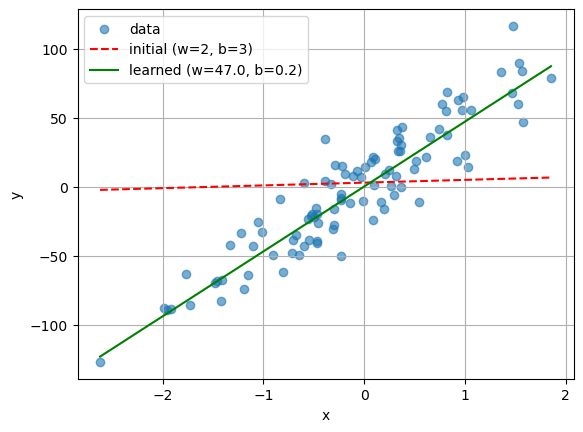

In [13]:
# final fit: data + the line SGD learned
x_ends = torch.tensor([x.min().item(), x.max().item()])

plt.scatter(x.numpy(), y.numpy(), alpha=0.6, label='data')
plt.plot(x_ends.numpy(), (2.0 * x_ends + 3.0).numpy(), 'r--', label='initial (w=2, b=3)')
plt.plot(x_ends.numpy(), (w * x_ends + b).numpy(), 'g', label=f'learned (w={w.item():.1f}, b={b.item():.1f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# compare my SGD to sklearn's SGDRegressor
from sklearn.linear_model import SGDRegressor

# Sklearn's SGD
ref = SGDRegressor(penalty=None).fit(x.numpy(), y.numpy().ravel())

print(f"my SGD:   w={w.item():.2f}  b={b.item():.2f}")
print(f"sklearn:  w={ref.coef_[0]:.2f}  b={ref.intercept_[0]:.2f}")

# which model actually fits the data better? lower MSE wins
def mse(w, b, X, Y):
    return ((w * X + b - Y) ** 2).mean().item()

import torch
mse_mine = mse(w, b, x, y.reshape(-1, 1))
mse_sk   = mse(torch.tensor(ref.coef_[0]), torch.tensor(ref.intercept_[0]), x, y.reshape(-1, 1))

print(f"my MSE:      {mse_mine:.2f}")
print(f"sklearn MSE: {mse_sk:.2f}")
print("better fit:", "mine" if mse_mine < mse_sk else "sklearn")


my SGD:   w=46.97  b=0.21
sklearn:  w=47.12  b=2.33
my MSE:      316.65
sklearn MSE: 312.22
better fit: sklearn


In [33]:
# fair comparison: same train/test split feeds BOTH models each run, averaged over many runs
import numpy as np
from sklearn.linear_model import SGDRegressor

def train_sgd(x_train, y_train, n_iter=2000, C=0.1):
    w = torch.tensor(2.0)   # same starting guess as the main loop
    b = torch.tensor(3.0)
    for i in range(n_iter):
        t = i + 1
        k = random.randint(0, len(x_train) - 1)
        x_b, y_b = x_train[k], y_train[k]
        residual = w * x_b + b - y_b        # pred - actual
        lr = C / (t ** 0.5)                 # the 1/sqrt(t) schedule
        w = w - lr * 2 * residual * x_b
        b = b - lr * 2 * residual
    return w.item(), b.item()

runs = 10
my = {"w": [], "b": [], "mse": []}
sk = {"w": [], "b": [], "mse": []}
X, Y = x, y.reshape(-1, 1)

for r in range(runs):
    # one split per run, shared by both models -> apples to apples
    x_tr, x_te, y_tr, y_te = train_test_split(X, Y, test_size=0.2)

    # my SGD
    w_m, b_m = train_sgd(x_tr, y_tr)
    my["w"].append(w_m)
    my["b"].append(b_m)
    my["mse"].append(mse(torch.tensor(w_m), torch.tensor(b_m), X, Y))

    # sklearn on the SAME training data
    ref = SGDRegressor(penalty=None).fit(x_tr.numpy(), y_tr.numpy().ravel())
    w_s, b_s = ref.coef_[0], ref.intercept_[0]
    sk["w"].append(w_s)
    sk["b"].append(b_s)
    sk["mse"].append(mse(torch.tensor(w_s), torch.tensor(b_s), X, Y))

print(f"averaged over {runs} runs (same split feeds both each run)\n")
print(f"{'':4}{'my_sgd':>12}{'sklearn':>12}")
for k in ("w", "b", "mse"):
    print(f"{k:<4}{np.mean(my[k]):>12.2f}{np.mean(sk[k]):>12.2f}")


averaged over 10 runs (same split feeds both each run)

          my_sgd     sklearn
w          47.25       46.97
b           1.75        2.09
mse       314.40      313.17
